Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix, roc_curve,
                             classification_report)

print("Libraries loaded successfully.")

Libraries loaded successfully.


Load Dataset

In [ ]:
# =============================================================================
# DATA LOADING
# Place creditcard.csv in the project root directory, OR configure Kaggle API
# credentials (kaggle.json) to enable automatic download.
# Kaggle API setup: https://www.kaggle.com/docs/api
# =============================================================================
import os

DATASET_PATH = "creditcard.csv"

if not os.path.exists(DATASET_PATH):
    print("Dataset not found locally. Attempting to download from Kaggle...")
    os.system("kaggle datasets download -d mlg-ulb/creditcardfraud --unzip")
    print("Download complete.")
else:
    print(f"Loading dataset from: {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH)
print(f"Dataset shape: {df.shape}")
print(f"
Class distribution:")
print(df["Class"].value_counts())
print(f"
Fraud percentage: {df["Class"].mean()*100:.3f}%")
print(f"
Missing values: {df.isnull().sum().sum()}")


Exploratory Data Analysis

=== BASIC STATISTICS ===

Total transactions: 284,807
Legitimate transactions: 284,315
Fraudulent transactions: 492

=== TRANSACTION AMOUNT STATISTICS ===
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


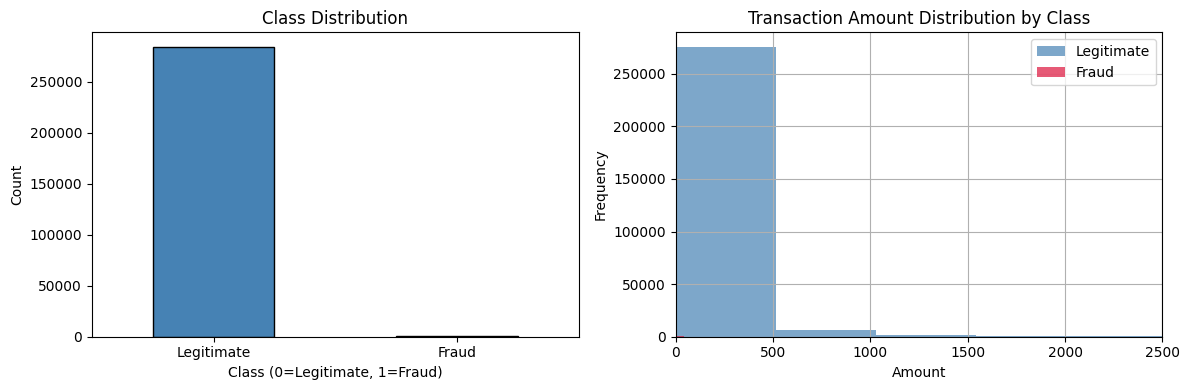

Plot saved.


In [ ]:
print("=== BASIC STATISTICS ===")
print(f"\nTotal transactions: {len(df):,}")
print(f"Legitimate transactions: {df['Class'].value_counts()[0]:,}")
print(f"Fraudulent transactions: {df['Class'].value_counts()[1]:,}")

print("\n=== TRANSACTION AMOUNT STATISTICS ===")
print(df.groupby('Class')['Amount'].describe().round(2))

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['Class'].value_counts().plot(kind='bar', ax=axes[0],
                                 color=['steelblue', 'crimson'],
                                 edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

# Amount distribution by class
df[df['Class']==0]['Amount'].hist(ax=axes[1], bins=50,
                                   alpha=0.7, color='steelblue',
                                   label='Legitimate')
df[df['Class']==1]['Amount'].hist(ax=axes[1], bins=50,
                                   alpha=0.7, color='crimson',
                                   label='Fraud')
axes[1].set_title('Transaction Amount Distribution by Class')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 2500)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

Rule-Based System

In [ ]:
# Define rule-based system
# Rule: Flag transaction as fraud if Amount exceeds 75th percentile
# of the overall transaction amount

threshold = df['Amount'].quantile(0.75)
print(f"Rule-based threshold (75th percentile): ${threshold:.2f}")

df['RuleBased_Pred'] = (df['Amount'] > threshold).astype(int)

# Evaluation
rb_precision = precision_score(df['Class'], df['RuleBased_Pred'])
rb_recall = recall_score(df['Class'], df['RuleBased_Pred'])
rb_f1 = f1_score(df['Class'], df['RuleBased_Pred'])
rb_roc = roc_auc_score(df['Class'], df['RuleBased_Pred'])

print(f"\n=== RULE-BASED SYSTEM RESULTS ===")
print(f"Precision : {rb_precision:.4f}")
print(f"Recall    : {rb_recall:.4f}")
print(f"F1-Score  : {rb_f1:.4f}")
print(f"ROC-AUC   : {rb_roc:.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(df['Class'], df['RuleBased_Pred']))

Rule-based threshold (75th percentile): $77.16

=== RULE-BASED SYSTEM RESULTS ===
Precision : 0.0024
Recall    : 0.3537
F1-Score  : 0.0049
ROC-AUC   : 0.5519

Confusion Matrix:
[[213287  71028]
 [   318    174]]


Train/Test Split

In [ ]:
# Features and target
X = df.drop(['Class', 'RuleBased_Pred'], axis=1)
y = df['Class']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class ratio in both sets
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size    : {X_test.shape[0]:,}")
print(f"\nTraining fraud cases : {y_train.sum()}")
print(f"Test fraud cases     : {y_test.sum()}")

Training set size: 227,845
Test set size    : 56,962

Training fraud cases : 394
Test fraud cases     : 98


Train Random Forest

In [ ]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # handles class imbalance
    n_jobs=-1                 # use all CPU cores
)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Training complete.")

# Predict
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"\nPredictions generated for {len(y_pred):,} test samples.")

Training Random Forest model...
Training complete.

Predictions generated for 56,962 test samples.


Evaluate Random Forest

In [ ]:
# Calculate metrics
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_roc = roc_auc_score(y_test, y_pred_proba)

print("=== RANDOM FOREST RESULTS ===")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Legitimate', 'Fraud']))

=== RANDOM FOREST RESULTS ===
Precision : 0.9605
Recall    : 0.7449
F1-Score  : 0.8391
ROC-AUC   : 0.9529

Confusion Matrix:
[[56861     3]
 [   25    73]]

Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



Comparison Table

In [ ]:
# Comparison table
results = {
    'Model': ['Rule-Based System', 'Random Forest'],
    'Precision': [rb_precision, rf_precision],
    'Recall': [rb_recall, rf_recall],
    'F1-Score': [rb_f1, rf_f1],
    'ROC-AUC': [rb_roc, rf_roc],
    'False Positives': [71028, 3],
    'False Negatives': [318, 25],
    'True Positives': [174, 73]
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
results_df[['Precision', 'Recall', 'F1-Score', 'ROC-AUC']] = \
    results_df[['Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4)

print("=== MODEL COMPARISON ===")
print(results_df.to_string())

# Save to CSV for report
results_df.to_csv('model_comparison.csv')
print("\nComparison table saved.")

=== MODEL COMPARISON ===
                   Precision  Recall  F1-Score  ROC-AUC  False Positives  False Negatives  True Positives
Model                                                                                                    
Rule-Based System     0.0024  0.3537    0.0049   0.5519            71028              318             174
Random Forest         0.9605  0.7449    0.8391   0.9529                3               25              73

Comparison table saved.


Visualizations

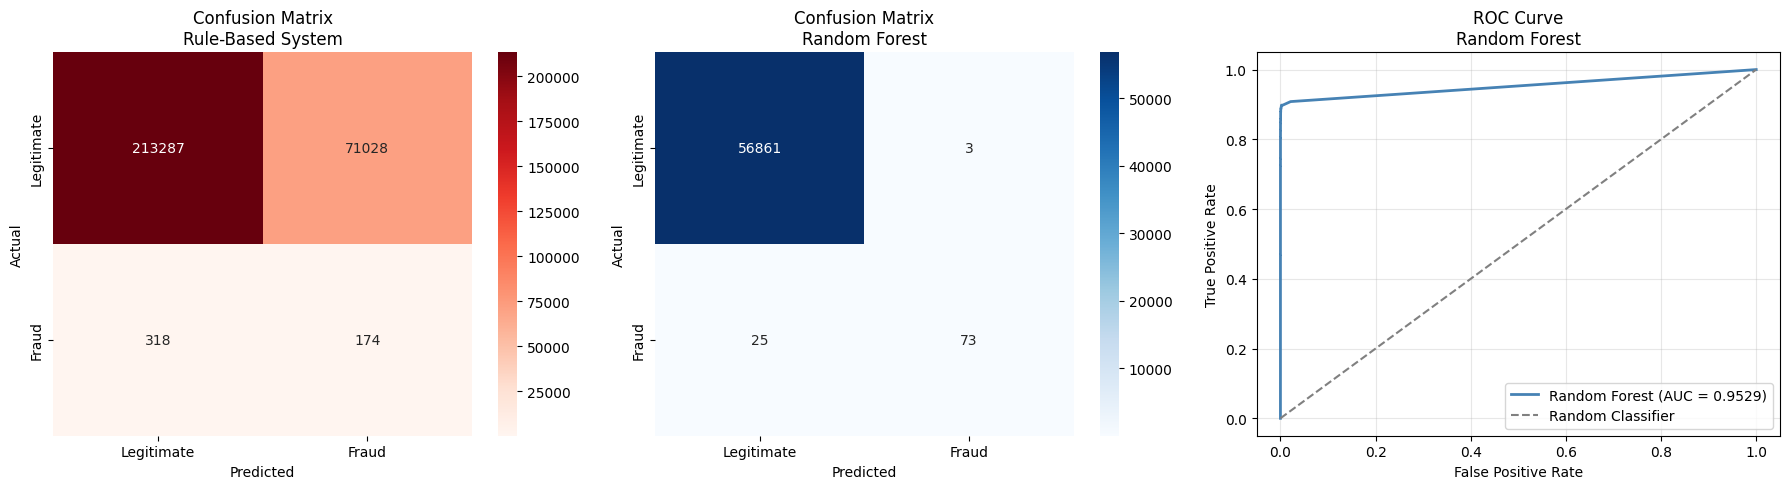

Visualizations saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix - Rule-Based
cm_rb = confusion_matrix(df['Class'], df['RuleBased_Pred'])
sns.heatmap(cm_rb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix\nRule-Based System')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix\nRandom Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# 3. ROC Curve - Random Forest
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[2].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Random Forest (AUC = {rf_roc:.4f})')
axes[2].plot([0, 1], [0, 1], color='gray',
             linestyle='--', label='Random Classifier')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve\nRandom Forest')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved.")

Feature Importance

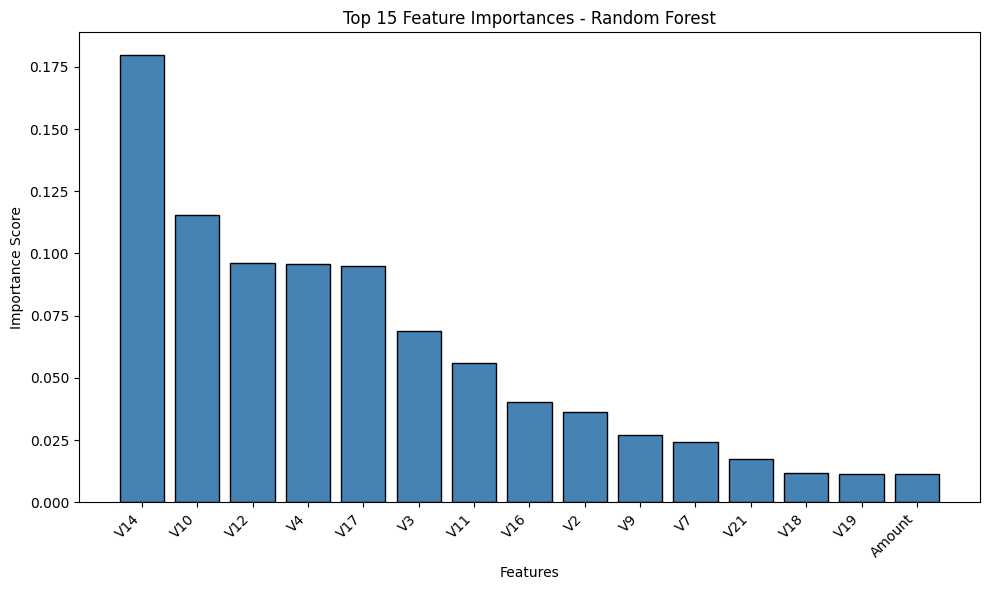


Top 10 most important features:
 1. V14        : 0.1799
 2. V10        : 0.1154
 3. V12        : 0.0962
 4. V4         : 0.0956
 5. V17        : 0.0951
 6. V3         : 0.0687
 7. V11        : 0.0561
 8. V16        : 0.0403
 9. V2         : 0.0363
10. V9         : 0.0269


In [ ]:
# Feature importance
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15 features

plt.figure(figsize=(10, 6))
plt.bar(range(15), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(15), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most important features:")
for i in range(10):
    print(f"{i+1:2}. {feature_names[indices[i]]:<10} : {importances[indices[i]]:.4f}")